## Artifical neural network (MINIST data set)

In [56]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

data = pd.DataFrame(X_train.reshape(X_train.shape[0], -1))
data.insert(0, 'label', y_train)

In [57]:
data.head()

,label,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [58]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000]. T
y_dev = data_dev[0]
x_dev = data_dev[1:n]

data_train = data[1000:m].T
y_train = data_train[0]
x_train = data_train[1:n]

In [59]:
x_train[:, 0].shape

(784,)

In [60]:
def init_params():
    w1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    w2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return w1, b1, w2, b2

def Relu(z):
    return np.maximum(0, z)

def Relu_deriv(z):
    return z > 0

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

def one_hot(y):
    one_hot_y = np.zeros((y.size, y.max() + 1))
    one_hot_y[np.arange(y.size), y] = 1
    one_hot_y = one_hot_y.T
    return one_hot_y

def forward_prop(x, w1, b1, w2, b2):
    z1 = w1.dot(x) + b1
    a1 = Relu(z1)
    z2 = w2.dot(a1) + b2
    a2 = softmax(z2)
    return z1, a1, z2, a2

def back_prop(z1, a1, z2, a2, w2, x, y):
    m = y.size
    one_hot_y = one_hot(y)
    dz2 = a2 - one_hot_y
    dw2 = 1/m * dz2.dot(a1.T)
    db2 = 1/m * np.sum(dz2, axis=1, keepdims=True)
    dz1 = w2.T.dot(dz2) * Relu_deriv(z1)
    dw1 = 1/m * dz1.dot(x.T)
    db1 = 1/m * np.sum(dz1, axis=1, keepdims=True)
    return dw1, db1, dw2, db2

def update_params(w1, b1, w2, b2, dw1, db1, dw2, db2, alpha):
    w1 = w1 - alpha * dw1
    b1 = b1 - alpha * db1
    w2 = w2 - alpha * dw2
    b2 = b2 - alpha * db2
    return w1, b1, w2, b2



In [61]:
def get_predictions(a2):
    return np.argmax(a2, 0)
def get_accuracy(predictions, y):
    print(predictions, y)
    return np.sum(predictions == y) / y.size

def gradient_descent(x, y, n_iter=1000, alpha=0.01):
    w1, b1, w2, b2 = init_params()
    for i in range(n_iter):
        z1, a1, z2, a2 = forward_prop(x, w1, b1, w2, b2)
        dw1, db1, dw2, db2 = back_prop(z1, a1, z2, a2, w2, x, y)
        w1, b1, w2, b2 = update_params(w1, b1, w2, b2, dw1, db1, dw2, db2, alpha)
        if (i % 10 == 0):
            predictions = get_predictions(a2)
            acc = get_accuracy(predictions, y)
            print("Iteration: ", i, " - Accuracy: ", acc)
    return w1, b1, w2, b2

In [62]:
w1, b1, w2, b2 = gradient_descent(x_train, y_train, 500, 0.1)

[8 7 6 ... 5 5 5] [9 2 0 ... 3 3 7]
Iteration:  0  - Accuracy:  0.07371186440677967
[6 6 6 ... 6 6 6] [9 2 0 ... 3 3 7]
Iteration:  10  - Accuracy:  0.09859322033898305
[6 6 6 ... 6 6 6] [9 2 0 ... 3 3 7]
Iteration:  10  - Accuracy:  0.09859322033898305
[6 6 6 ... 6 6 6] [9 2 0 ... 3 3 7]
Iteration:  20  - Accuracy:  0.09859322033898305
[6 6 6 ... 6 6 6] [9 2 0 ... 3 3 7]
Iteration:  20  - Accuracy:  0.09859322033898305
[6 6 6 ... 6 6 6] [9 2 0 ... 3 3 7]
Iteration:  30  - Accuracy:  0.09859322033898305
[6 6 6 ... 6 6 6] [9 2 0 ... 3 3 7]
Iteration:  30  - Accuracy:  0.09859322033898305
[6 6 6 ... 6 6 6] [9 2 0 ... 3 3 7]
Iteration:  40  - Accuracy:  0.09859322033898305
[6 6 6 ... 6 6 6] [9 2 0 ... 3 3 7]
Iteration:  40  - Accuracy:  0.09859322033898305
[6 6 6 ... 6 6 6] [9 2 0 ... 3 3 7]
Iteration:  50  - Accuracy:  0.09859322033898305
[6 6 6 ... 6 6 6] [9 2 0 ... 3 3 7]
Iteration:  50  - Accuracy:  0.09859322033898305
[6 6 6 ... 6 6 6] [9 2 0 ... 3 3 7]
Iteration:  60  - Accuracy:  0

In [63]:
def test_predictions(index, w1, b1, w2, b2):
	current_image = X_test[index]
	prediction = get_predictions(forward_prop(current_image.reshape(-1, 1), w1, b1, w2, b2)[3])
	label = y_test[index]
	print("Prediction: ", prediction[0])
	print("Label: ", label)
	
	current_image = current_image.reshape((28, 28)) * 255
	plt.gray()
	plt.imshow(current_image, interpolation='nearest')
	plt.show()


In [66]:
dev_predictions = get_predictions(forward_prop(x_dev, w1, b1, w2, b2))
get_accuracy(dev_predictions, y_dev)

[[3 3 3 ... 3 3 3]
 [3 3 3 ... 3 3 3]
 [3 3 3 ... 3 3 3]
 ...
 [3 3 3 ... 3 3 3]
 [3 3 3 ... 3 3 3]
 [3 3 3 ... 3 3 3]] [9 9 5 4 7 0 7 7 5 7 5 5 5 5 2 9 1 1 9 6 3 6 1 1 1 0 5 5 8 9 6 7 0 2 2 0 2
 0 2 5 2 8 8 9 1 8 1 5 5 6 2 9 4 2 6 9 6 4 0 8 3 1 3 8 0 9 0 9 9 2 0 9 6 3
 2 1 4 7 1 4 3 5 9 2 2 4 0 5 5 1 0 7 6 2 0 8 3 0 0 0 8 6 7 8 0 5 4 2 4 1 0
 0 2 0 2 0 0 3 6 9 9 0 4 1 3 9 4 6 4 6 9 0 9 6 8 1 9 6 1 8 6 6 3 1 6 6 1 2
 7 3 4 2 3 4 2 8 5 4 1 9 9 9 9 6 0 5 6 7 1 4 5 6 0 6 5 6 1 0 8 4 7 5 4 2 5
 7 9 7 0 7 3 9 1 4 7 9 7 7 2 5 0 6 9 1 9 3 4 0 2 8 0 4 7 9 3 1 7 5 6 1 8 7
 1 0 6 9 7 8 0 7 6 9 5 1 3 9 0 2 0 3 0 6 4 9 5 0 8 9 4 9 6 1 8 1 2 1 8 2 6
 3 7 0 2 3 5 9 6 7 5 4 9 0 7 0 9 5 6 9 9 3 7 3 2 5 1 1 9 8 3 8 9 5 9 3 5 9
 1 7 7 0 6 6 5 1 6 2 3 0 8 1 6 7 7 2 1 8 7 6 6 3 8 2 3 9 3 1 3 7 0 3 1 8 4
 8 6 8 3 9 0 1 7 6 9 6 1 9 5 8 6 0 3 7 4 9 7 1 1 4 5 7 1 7 5 6 9 2 5 5 4 3
 1 7 4 1 8 4 2 3 3 2 8 3 7 0 2 5 0 4 5 2 0 3 7 2 8 4 3 5 9 7 9 4 8 5 1 8 3
 6 5 1 0 0 9 8 3 7 2 3 0 9 7 0 3 7 9 9 8 1 2 4 5 2 7 8 

np.float64(1.04)

Prediction:  1
Label:  1


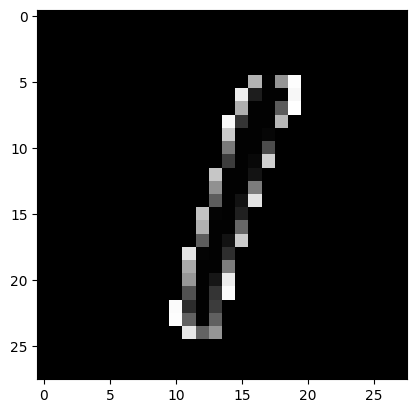

In [70]:

test_predictions(5, w1, b1, w2, b2)